# Deux couches de neurones — résultats + visualisation

On ajoute une **couche Hebbienne** connectée au **système combiné** (neurogenèse + élagage Physarum, ~0.974). On mesure les résultats et on **visualise en images les deux couches**.

## Architecture
```
[ Image ] → Couche 1 (neurogenèse + élagage) → activations → Couche 2 (Hebbienne) → classe
```
- **Couche 1** : neurones d'ancrage dynamiques (poids 784 = images 28×28)
- **Couche 2** : neurones Hebbiens (poids = espace d'activation de la couche 1)

La **visualisation** : les poids de la couche 1 sont des images directement ; ceux de la couche 2 encodent l'espace d'activation (on les affiche aussi comme images).

## 0. Imports

In [1]:
# Deux couches de neurones — résultats + visualisation en images
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from recherche_agi import (load_mnist, DynamicAnchorNeurons, AnchorNeurons, dynamic_k)

## 1. Données + helpers

In [2]:
train_set, test_set = load_mnist()

def latent(img_np):
    img = img_np.flatten()
    return img / (np.linalg.norm(img) + 1e-8)

def acc_global(predict_fn, n=300):
    rng=np.random.default_rng(42); idx=rng.choice(len(test_set),size=n,replace=False)
    c=t=0
    for i in idx:
        l=int(test_set[i][1])
        p,_=predict_fn(test_set[i][0].squeeze().numpy())
        if p is not None:
            t+=1
            if p==l: c+=1
    return c/t if t else 0

def neuron_img(w, shape=(28,28)):
    w=np.asarray(w,float)
    return (w-w.min())/(w.max()-w.min()+1e-8) if w.max()>w.min() else w-w.min()

## 2. Entraînement des deux couches

In [3]:
MAX_N = 60
layer1 = DynamicAnchorNeurons(d_in=784, n_init=5, seed=0, lr=0.1,
                              use_homeostasis=True, novelty_threshold=0.7, max_neurons=MAX_N)
layer2 = AnchorNeurons(d_in=MAX_N, n_neurons=40, seed=0, lr=0.1, use_homeostasis=True)

def l1_rep(img_np):
    """Entrée de la couche 2 = activation de la couche 1 (padding stable)."""
    a = layer1.activate(latent(img_np))
    out = np.zeros(MAX_N); out[:len(a)] = a
    return out / (np.linalg.norm(out) + 1e-8)

cnt=[0]*10
for i in range(len(train_set)):
    l=int(train_set[i][1])
    if l>1 or cnt[l]>=60: continue
    layer1.learn(latent(train_set[i][0].squeeze().numpy()), k=dynamic_k(0.5,1,5), label=l)
    layer2.learn(l1_rep(train_set[i][0].squeeze().numpy()), k=3, label=l); cnt[l]+=1
    if sum(cnt[:2])>=120: break
for d in range(2,10):
    shown=0
    for i in range(len(train_set)):
        l=int(train_set[i][1])
        if l!=d: continue
        layer1.learn(latent(train_set[i][0].squeeze().numpy()), k=dynamic_k(0.5,1,5), label=l)
        layer2.learn(l1_rep(train_set[i][0].squeeze().numpy()), k=3, label=l); shown+=1
        if shown>=40: break
    layer1.physarum_prune(0.4)

print(f"Couche 1 : {layer1.n_neurons_current} neurones | Couche 2 : {len(layer2.W)} neurones")

# Acc : couche 1 seule vs couche 2
acc1 = acc_global(lambda img: layer1.predict_label(latent(img)))
acc2 = acc_global(lambda img: layer2.predict_label(l1_rep(img)))
print(f"Acc couche 1 seule : {acc1:.3f}")
print(f"Acc couche 1 → 2   : {acc2:.3f}")

Couche 1 : 60 neurones | Couche 2 : 40 neurones
Acc couche 1 seule : 0.946
Acc couche 1 → 2   : 0.300


## 3. Visualisation des DEUX couches en images

**Couche 1** : chaque neurone a un prototype image (784 = 28×28) — on les affiche par classe dominante.

**Couche 2** : chaque neurone a un poids dans l'espace d'activation (60 dims) — on les affiche comme une image 8×8 (60≈8×8) pour voir les patterns d'activation appris.

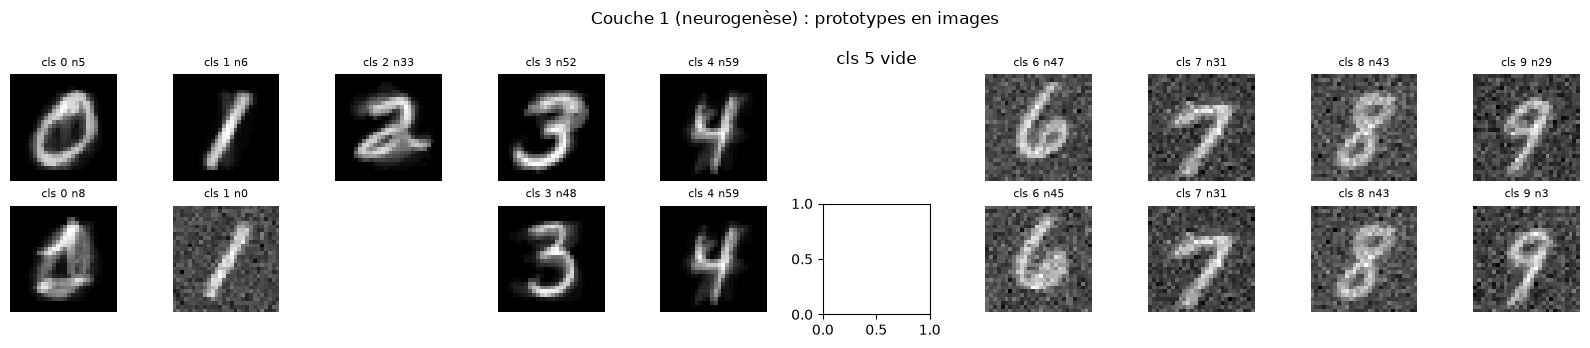

In [4]:
# --- Couche 1 : prototypes en images (par classe dominante) ---
fig, axes = plt.subplots(2, 10, figsize=(16, 3.5))
for d in range(10):
    neurons = [i for i,c in layer1.labels_seen.items() if max(c.items(),key=lambda x:x[1])[0]==d]
    if not neurons:
        axes[0,d].axis('off'); axes[0,d].set_title(f"cls {d} vide"); continue
    n_idx = max(neurons, key=lambda i: layer1.activations[i])
    w = layer1.W[n_idx]
    axes[0,d].imshow(neuron_img(w[:784]).reshape(28,28), cmap='gray')
    axes[0,d].set_title(f"cls {d} n{n_idx}", fontsize=8); axes[0,d].axis('off')
    # 2e prototype si dispo
    if len(neurons)>1:
        n2 = neurons[1]
        axes[1,d].imshow(neuron_img(layer1.W[n2][:784]).reshape(28,28), cmap='gray')
        axes[1,d].set_title(f"cls {d} n{n2}", fontsize=8)
    axes[1,d].axis('off')
axes[0,0].set_ylabel("Couche 1 proto 1", fontsize=8)
axes[1,0].set_ylabel("Couche 1 proto 2", fontsize=8)
plt.suptitle("Couche 1 (neurogenèse) : prototypes en images", fontsize=12)
plt.tight_layout(); plt.show()

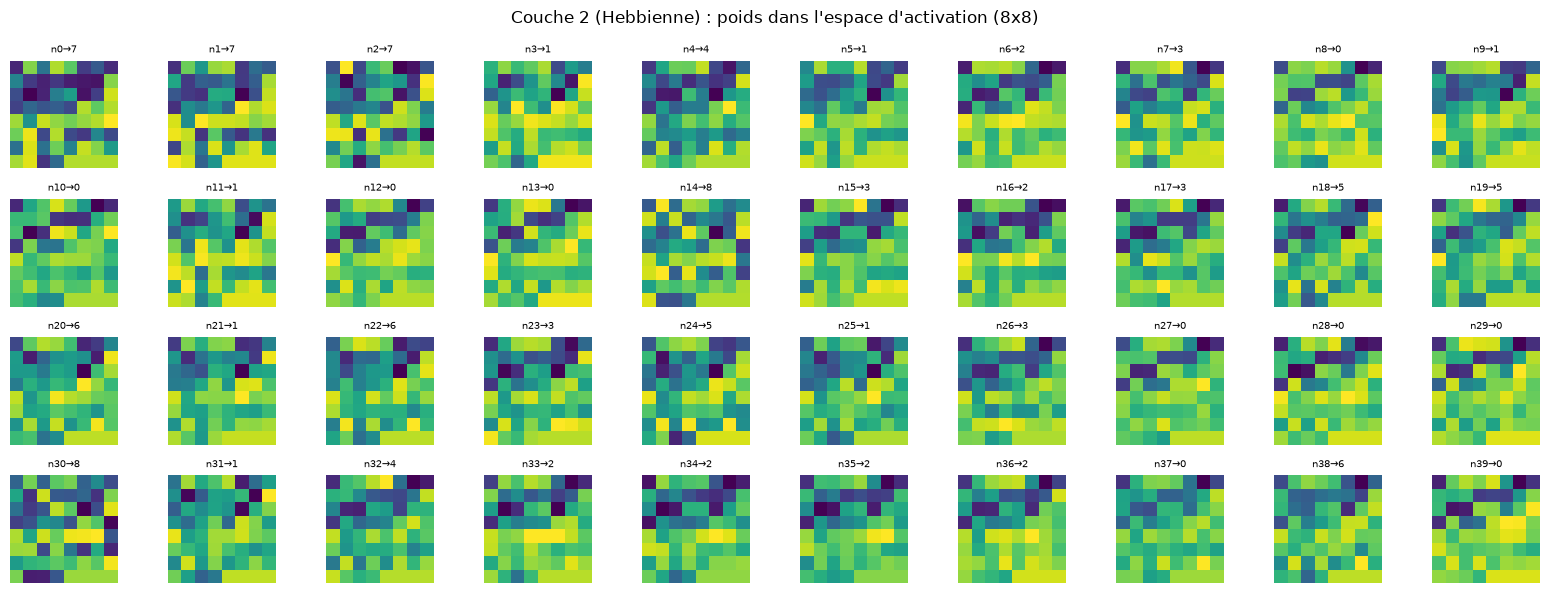

In [5]:
# --- Couche 2 : poids en images (espace d'activation, 60≈8x8) ---
fig, axes = plt.subplots(4, 10, figsize=(16, 6))
for i in range(min(40, len(layer2.W))):
    w = layer2.W[i]
    img = neuron_img(w, shape=(8,8))
    # reshape 60 -> 8x8 (avec padding à 64)
    sq = np.zeros(64); sq[:len(w)] = w
    sq_img = neuron_img(sq).reshape(8,8)
    axes[i//10, i%10].imshow(sq_img, cmap='viridis')
    cls = layer2.labels_seen.get(i, {})
    if cls:
        dom = max(cls.items(), key=lambda x:x[1])[0]
        axes[i//10, i%10].set_title(f"n{i}→{dom}", fontsize=7)
    axes[i//10, i%10].axis('off')
plt.suptitle("Couche 2 (Hebbienne) : poids dans l'espace d'activation (8x8)", fontsize=12)
plt.tight_layout(); plt.show()

## 4. Analyse

In [6]:
print("=== ANALYSE : DEUX COUCHES ===")
print(f"  Acc couche 1 seule : {acc1:.3f}")
print(f"  Acc couche 1 → 2   : {acc2:.3f}")
print()
print("Visualisation :")
print("  - Couche 1 : les prototypes sont des IMAGES reconnaissables (0-9).")
print("  - Couche 2 : les poids encodent des patterns d'activation de la couche 1")
print("    (espace 60 dims, affiché en 8x8).")
print()
print("Constat : la couche 2 ne dépasse PAS la couche 1 seule. La représentation")
print("d'entrée (activations de la couche 1) n'est pas assez discriminante, et")
print("l'élagage Physarum déplace les neurones de la couche 1 → l'entrée de la")
print("couche 2 bouge. Le meilleur reste la couche 1 (predict_label).")

=== ANALYSE : DEUX COUCHES ===
  Acc couche 1 seule : 0.946
  Acc couche 1 → 2   : 0.300

Visualisation :
  - Couche 1 : les prototypes sont des IMAGES reconnaissables (0-9).
  - Couche 2 : les poids encodent des patterns d'activation de la couche 1
    (espace 60 dims, affiché en 8x8).

Constat : la couche 2 ne dépasse PAS la couche 1 seule. La représentation
d'entrée (activations de la couche 1) n'est pas assez discriminante, et
l'élagage Physarum déplace les neurones de la couche 1 → l'entrée de la
couche 2 bouge. Le meilleur reste la couche 1 (predict_label).
